In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from matplotlib import rcParams
import itertools

rcParams['figure.figsize'] = 8, 5

from venn import venn
from venn import pseudovenn

In [ ]:
# convert normalized abundance data into tab separated dataframe
## proteome
file = '../data/Proteomics_data.xlsx'
protID = 'Protein'
series = ['Uninfected', '1hr(-abx)','2hr(+abx)','4hr(+abx)','7hr(+abx)', '24hr(+abx)']

data = pd.read_excel(file, sheet_name='Normalized_Abundance', index_col=protID)
series_columns = []
for column in data.columns:
    for point in series:
        if point in column and point[0]==column[0]:
            series_columns.append(column)
data = data[series_columns].dropna()
data = data.T

drop_cols = [i for i in data.columns if len(i.split(':')) > 1]
data = data.drop(drop_cols, axis=1)

new_col_names = []
for col in data.columns:
    if len(col.split('-')) > 1:
        new_col_names.append(col.split('-')[0])
    else:
        new_col_names.append(col)
data.columns = new_col_names

data.to_csv('../data/norm_macro_proteome.csv', sep='\t')


read in proteomics data and preprocess

In [ ]:
# read in normalized proteome, phosphoproteome data
proteome_data = pd.read_csv('../data/norm_macro_proteome.csv', index_col=0, sep='\t').T


In [3]:
# average data across each protein/site
## proteome
proteome_data_avg = pd.DataFrame(columns=proteome_data.columns, index=set([i.split('.')[0] for i in proteome_data.index]))
for protein in proteome_data_avg.index:
    proteome_data_avg.loc[protein] = proteome_data.loc[proteome_data.index.str.contains(protein)].mean()
proteome_data_avg= proteome_data_avg.astype('float')
proteome_data_avg_anova = proteome_data_avg.astype('float').T

# Welch's t-test on each timepoint vs uninfected timepoint and one-way ANOVA

In [23]:
from pkg.query_objects import ProteinDataset
from pkg.query_objects import Protein
import pkg.filter_objects as filt

proteome data - t-test

In [38]:
# set tuples of timeseries for pairwise tests
## perform test on PROTEOME data 
data = proteome_data_avg
# time_series = [('1hr'),('2hr'),('4hr','7hr'),('24hr')]
time_series = [('Uninfected','1hr'),('Uninfected','2hr'),('Uninfected','4hr'),('Uninfected','7hr'),('Uninfected','24hr')]

In [39]:
file = '../data/Proteomics_data.xlsx'
protID = 'Protein'
series = ['Uninfected', '1hr(-abx)','2hr(+abx)','4hr(+abx)','7hr(+abx)', '24hr(+abx)']

info_data = pd.read_excel(file, sheet_name='Regular_Normalized', index_col=protID)

desc=[]
for index in data.index:
    desc.append(info_data.loc[info_data.index.str.contains(index)].iloc[0]['Description'])

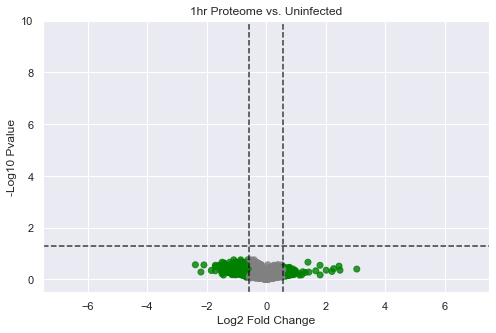

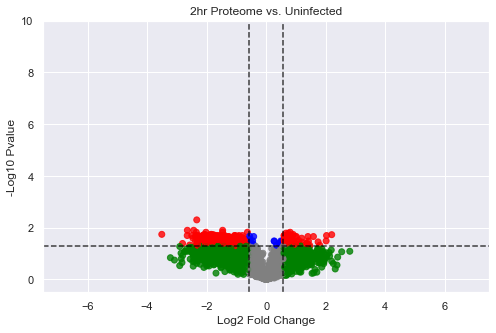

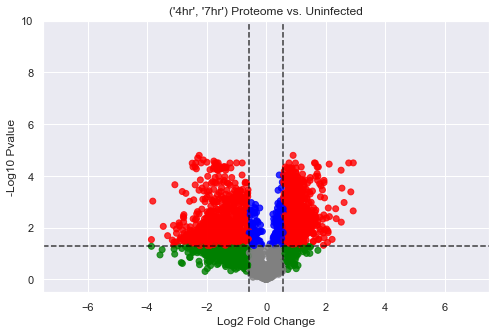

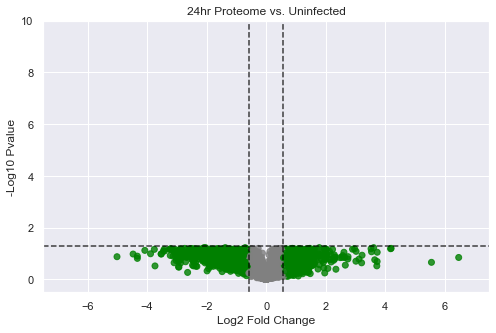

In [40]:
# Welch’s t-test, which does not assume equal population variance
ttest = pd.DataFrame(index=data.index)
ttest['Description'] = desc 
for times in time_series:
    if type(times) == tuple:
        cluster = [col for t in times for col in data.columns if t in col and col[0] == t[0]]
    else:
        cluster = [col for col in data.columns if times in col and col[0] == times[0]]
    other = [col for col in data.columns if 'Uninfected' in col]
    #other = list(set(data.columns) - set(cluster))
    data_t1 = data.loc[:, other].T
    data_t2 = data.loc[:, cluster].T
    tstat =  ttest_ind(data_t1, data_t2, equal_var=False).statistic
    pval = ttest_ind(data_t1, data_t2, equal_var=False).pvalue
    fc = list(np.log2(data_t2.mean()) - np.log2(data_t1.mean()))
    ttest['{}_STAT'.format(times)] = tstat
    ttest['{}_LOG2FC'.format(times)] = fc
    ttest['{}_PVAL'.format(times)] = pval
    adj_pvals = multipletests(pvals=pval, alpha=0.05, method='fdr_bh')[1]
    ttest['{}_ADJPVAL'.format(times)] = adj_pvals
    
    x = fc
    pval = adj_pvals
    y = -1*np.log10(pval)
    
    cvec = []
    cutoff=0.05
    for i in range(len(x)):
        if abs(x[i]) >= 0.58 and y[i] >= -1*np.log10(cutoff):
            cvec.append('red')
        elif abs(x[i]) >= 0.58 and y[i] < -1*np.log10(cutoff):
            cvec.append('green')
        elif abs(x[i]) < 0.58 and y[i] >= -1*np.log10(cutoff):
            cvec.append('blue')
        else:
            cvec.append('grey')


    plt.xlim(-7.5,7.5)
    plt.ylim(-0.5,10)
    plt.axvline(x=0.58, linestyle='--', c='black', alpha=0.75)
    plt.axvline(x=-0.58, linestyle='--', c='black', alpha=0.75)
    plt.axhline(y=-1*np.log10(cutoff), linestyle='--', c='black', alpha=0.75)
    plt.scatter(x, y, c=cvec, alpha=0.8)
    plt.xlabel('Log2 Fold Change')
    plt.ylabel('-Log10 Pvalue')
    plt.title('{} Proteome vs. Uninfected'.format(times))
    plt.show()
    plt.savefig('../results/ttests/standard/{}_Uninfected_proteome_vol.pdf'.format(times)) # SUPP FIG 1
    plt.close()

In [41]:
# save ttest results
for times in time_series:
    master=pd.DataFrame(index=ttest.index)
    master['{}_STAT'.format(times)] = ttest['{}_STAT'.format(times)]
    master['{}_LOG2FC'.format(times)] = ttest['{}_LOG2FC'.format(times)]
    master['{}_PVAL'.format(times)] = ttest['{}_PVAL'.format(times)]
    master['{}_ADJPVAL'.format(times)] = ttest['{}_ADJPVAL'.format(times)]
    
with pd.ExcelWriter('../data/Proteomics_data.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    anova.sort_index().to_excel(writer, sheet_name='individual_ttest', index=True)
#     master.to_csv('../results/ttests/clusters/{}_proteome_ttest.csv'.format(times))

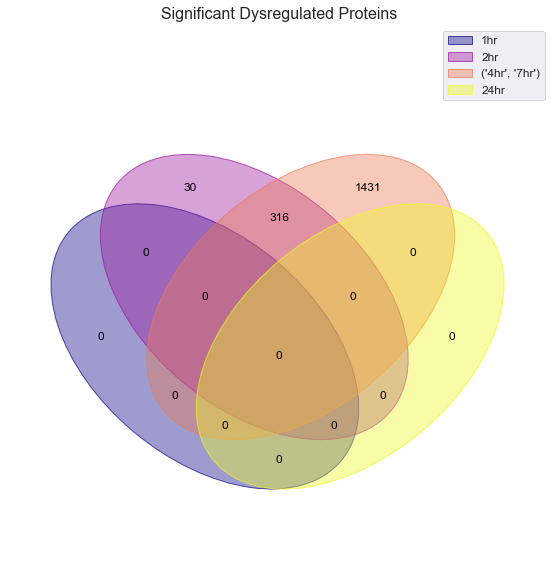

In [49]:
# create venn diagram of dysregulated phosphoproteins
d = {i:[] for i in time_series}
for times in time_series:
    for index in ttest.index:
        fc = ttest.loc[index]['{}_LOG2FC'.format(times)]
        adjp = ttest.loc[index]['{}_ADJPVAL'.format(times)]
        if abs(fc) >= 0.58 and adjp <= 0.05:
            d[times].append(index)
            
v = venn({k:set(v) for k,v in d.items()}, cmap='plasma', figsize=(10,10), fontsize=12)
plt.title('Significant Dysregulated Proteins', fontsize=16)
plt.savefig('../results/ttests/standard/proteome_venn.pdf') # SUPP FIG 1
plt.show()

In [20]:
data = proteome_data_avg
anova = pd.DataFrame(index=data.index)

# add gene name columns for uniprot
uniprot = pd.read_csv('../data/uniprot/prot_uniprot.tsv', sep='\t', index_col=0)
gene_names = []
for index in anova.index:
    try:
        gene_names.append(uniprot.loc[index]['Gene names'])
    except:
        gene_names.append('N/A')
anova['GENE_NAMES']=gene_names
prot_names = []
for index in anova.index:
    try:
        prot_names.append(uniprot.loc[index]['Protein names'])
    except:
        prot_names.append('N/A')
anova['PROT_NAMES']=prot_names
# anova

,GENE_NAMES,PROT_NAMES
Q13136,PPFIA1 LIP1,Liprin-alpha-1 (LAR-interacting protein 1) (LI...
Q96SB4,SRPK1,SRSF protein kinase 1 (EC 2.7.11.1) (SFRS prot...
Q5T200,ZC3H13 KIAA0853,Zinc finger CCCH domain-containing protein 13
Q5JSP0,FGD3 ZFYVE5,"FYVE, RhoGEF and PH domain-containing protein ..."
Q08170,SRSF4 SFRS4 SRP75,Serine/arginine-rich splicing factor 4 (Pre-mR...
...,...,...
O75376,NCOR1 KIAA1047,Nuclear receptor corepressor 1 (N-CoR) (N-CoR1)
P35580,MYH10,"Myosin-10 (Cellular myosin heavy chain, type B..."
Q5JTD0,TJAP1 PILT TJP4,Tight junction-associated protein 1 (Protein i...
O00559,EBAG9 RCAS1,Receptor-binding cancer antigen expressed on S...


In [21]:
d={}
# data = data.T
time_series = [('1hr'),('2hr'),('4hr','7hr'),('24hr')]
for times in time_series:
    if type(times) == tuple:
        cluster = [col for t in times for col in data.columns if t in col and col[0] == t[0]]
    else:
        cluster = [col for col in data.columns if times in col and col[0] == times[0]]
    other = [col for col in data.columns if 'Uninfected' in col]
    data_t1 = data.loc[:, other].T
    data_t2 = data.loc[:, cluster].T
    fc = list(np.log2(data_t2.mean()) - np.log2(data_t1.mean()))
    d[times]=fc

In [22]:
anova['UNIF_1H_LOG2FC'] = d['1hr']
anova['UNIF_2H_LOG2FC'] = d['2hr']
anova['UNIF_4/7H_LOG2FC'] = d[('4hr', '7hr')]
anova['UNIF_24H_LOG2FC'] = d['24hr']

In [23]:
from pkg.query_objects import ProteinDataset
from pkg.query_objects import Protein
import pkg.filter_objects as filt

In [24]:
data=data.T
test, mult_test = filt.ANOVA_oneway(values=data.values, labels=data.index, measures=data.columns, conditions=['Uninfected', '1hr(-abx)','2hr(+abx)','4hr(+abx)','7hr(+abx)', '24hr(+abx)'], alpha=0.05, method='fdr_bh')

In [26]:
anova['F_STAT']=test.statistic
anova['PVAL']=test.pvalue
anova['ADJPVAL']=mult_test[1]

In [ ]:
# save data
# anova.sort_index().to_csv('../data/PHOS_ANOVA.csv', index=True)
with pd.ExcelWriter('../data/Proteomics_data.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    anova.sort_index().to_excel(writer, sheet_name='clusters_anova_test', index=True)


# PCA

In [66]:
from pkg.query_objects import ProteinDataset
from pkg.query_objects import Protein

import pandas as pd
import numpy as np
import seaborn as sns; sns.set(); sns.set_style('white')
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
import pickle


with open('../data/macro_df_filt_05.obj', 'rb') as input_file:
    macro_df_filt = pickle.load(input_file)
print(macro_df_filt.values.shape)

(17, 1062)
(17, 3407)


generate PCA for proteome data 

In [95]:
data_vals = macro_df_filt.values
scaler = StandardScaler()
scaler.fit(data_vals)
scaled_df = pd.DataFrame(data=scaler.transform(data_vals), columns=macro_df_filt.measures, index=macro_df_filt.samples).T

In [96]:
scaled_df_avg = pd.DataFrame(columns=scaled_df.columns, index=set([i.split('.')[0] for i in scaled_df.index]))
for protein in scaled_df_avg.index:
    scaled_df_avg.loc[protein] = scaled_df.loc[scaled_df.index.str.contains(protein)].mean()
scaled_df_avg = scaled_df_avg.astype('float')

n_components = 10
pca = PCA(n_components=n_components)
# pca_df = pd.DataFrame(data=pca.fit_transform(scaled_df_avg.T), index=scaled_df_avg.T.index).T
pca_df = pd.DataFrame(data=pca.fit_transform(scaled_df.T), index=scaled_df.T.index).T

print('pca shape {}'.format(pca_df.shape))
pca_df = pca_df.iloc[[0,1]].T

pca shape (10, 17)


In [97]:
rcParams['figure.figsize'] = 10,7
label_color_dict =  {'Uninfected': 'white', '1hr(-abx)': 'lightgrey', '2hr(+abx)': 'dimgrey', '4hr(+abx)': 'lightcoral', '7hr(+abx)': 'indianred', '24hr(+abx)': 'darkred'}
hvec=[]
for i in pca_df.index:
    for j in label_color_dict.keys():
        if j in i and j[0]==i[0]:
            hvec.append(j)
pca_df['time'] = hvec
for time in ['Uninfected', '1hr(-abx)','2hr(+abx)','4hr(+abx)','7hr(+abx)', '24hr(+abx)']:
    plot_df = dict(list(pca_df.groupby(['time'])))[time]
    color=label_color_dict[time]
    plt.scatter(x=plot_df[0], y=plot_df[1], 
                c=[color]*len(plot_df), marker='s', s=150, alpha=0.85, label='{}'.format(time),edgecolor='black')


plt.title('PCA: Proteome (adjP<0.05)', fontsize=20)
plt.xlabel('PC1 ({:.2f}%)'.format(pca.explained_variance_ratio_[0]*100), fontsize=16)
plt.ylabel('PC2 ({:.2f}%)'.format(pca.explained_variance_ratio_[1]*100), fontsize=16)
plt.legend(frameon=True, shadow=True,
           bbox_to_anchor=(1.01, 1.01), loc='upper left', 
           title='Time', fontsize=16)
plt.tight_layout()
# plt.show()
plt.savefig('../results/PCA/pca_prot_05.pdf',bbox_inches='tight')  # FIG 1
plt.close()